# 🛡️ Adversarial Attacks & Defenses on Deep Neural Networks
---

## 📝 Project Overview
This project investigates the inherent vulnerabilities of Deep Neural Networks (DNNs) through the lens of adversarial machine learning. The primary objective is to design, implement, and rigorously evaluate **four white-box adversarial attacks** and **three distinct defense strategies** on a ResNet-20 architecture using the CIFAR-10 dataset.

---

## 👤 Team & Context
* **Team ID**: 1
* **Team Members**: Arvin Baghal Asl (403105793) & Arash Akbari (403105714)
* **Course**: Artificial Intelligence - Spring 2026
* **Framework**: PyTorch
* **Dataset**: CIFAR-10 (Normalized to [0, 1])
* **Target Model**: ResNet-20

---

## 🗺️ Roadmap & Implementation Status

### Phase 1: Foundation
- [ ] Environment Setup & Data Loading
- [ ] Model Encapsulation (Custom Normalize Layer)

### Phase 2: Adversarial Attacks (White-Box)
- [ ] **FGSM** (Fast Gradient Sign Method)
- [ ] **PGD** (Projected Gradient Descent)
- [ ] **DeepFool**
- [ ] **C&W ($L_2$)**

### Phase 3: Defense Mechanisms
- [ ] **Adversarial Training**
- [ ] **Randomized Smoothing**
- [ ] **Diffusion Purification** (DiffPure)

### Phase 4: Analysis & Reporting
- [ ] Cross-Evaluation Heatmap
- [ ] Sample Visualizations
- [ ] Final Analysis of Robustness Trade-offs

---

## Imports and Setup

In [ ]:
# --- Core PyTorch ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

# --- Data & Vision Utilities ---
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
from diffusers import UNet2DModel, DDIMScheduler

# --- Visualization & Analysis ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd

# --- System & Math ---
import os
import math
import copy

# define our device for GPU acceleration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# [0, 255] -> [0, 1]
transform = transforms.Compose([transforms.ToTensor()])

# download and load training and test sets
#train_set = CIFAR10(root='./data', train=True, transform=transform, download=True)
#test_set = CIFAR10(root='./data', train=False, transform=transform, download=True)

train_set = CIFAR10(root='/content/drive/MyDrive/CIFAR10_Backup/data', train=True, transform=transform, download=False)
test_set = CIFAR10(root='/content/drive/MyDrive/CIFAR10_Backup/data', train=False, transform=transform, download=False)

# total len should be equal to 60,000
total_images = len(train_set) + len(test_set)
print(f"Number of total CIFAR-10 images: {total_images}")
print("Train Set Size: ", len(train_set))
print("Test Set Size: ", len(test_set))
# print classes
cifar10_classes = train_set.classes
print("Number of Classes: ", len(cifar10_classes))
print("Classes: ", cifar10_classes)


Number of total CIFAR-10 images: 60000
Train Set Size:  50000
Test Set Size:  10000
Number of Classes:  10
Classes:  ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# create the destination directory
!mkdir -p /content/drive/MyDrive/CIFAR10_Backup
# copy the data
!cp -r ./data /content/drive/MyDrive/CIFAR10_Backup

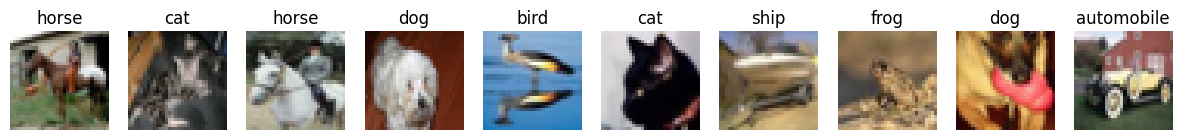

In [ ]:
# create a DataLoader for the first batch
loader = DataLoader(train_set, batch_size=10, shuffle=True)
images, labels = next(iter(loader))

# plotting to see some of the dataset images
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    # (Channel, Height, Width) -> (H, W, C)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(train_set.classes[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
cifar10_mean = train_set.data.mean(axis=(0, 1, 2)) / 255.0
cifar10_std = train_set.data.std(axis=(0, 1, 2)) / 255.0

print("train set shape: ", train_set.data.shape)
print("train set mean (RGB): ", cifar10_mean)
print("train set std (RGB): ", cifar10_std)

# normalize layer
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        # force float32 type using dtype=torch.float32
        self.register_buffer('mean', torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std, dtype=torch.float32).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


train set shape:  (50000, 32, 32, 3)
train set mean (RGB):  [0.49139968 0.48215841 0.44653091]
train set std (RGB):  [0.24703223 0.24348513 0.26158784]


In [ ]:
# Dynamic Load & Backup Pre-trained Model

# Path to save/load the model in your Google Drive backup folder
model_save_path = '/content/drive/MyDrive/CIFAR10_Backup/resnet20_cifar10.pth'

# 1. Check if the model is already loaded in the current active session
if 'resnet20_base' in globals():
    print("Model is already loaded in the current active session. Skipping...")
else:
    # 2. Check if the saved model file exists in Google Drive to load offline
    if os.path.exists(model_save_path):
        print("Loading pre-trained ResNet-20 model from Google Drive backup...")
        try:
            target_device = device if 'device' in globals() else 'cpu'
            resnet20_base = torch.load(model_save_path, map_location=target_device, weights_only=False)
            print("Model loaded successfully from Google Drive backup!")
        except Exception as e:
            print(f"Failed to load model from Google Drive: {e}")
            print("Downloading from torch.hub instead...")
            resnet20_base = torch.hub.load(
                "chenyaofo/pytorch-cifar-models",
                "cifar10_resnet20",
                pretrained=True,
                trust_repo=True
            )
    else:
        # 3. If not found anywhere, download from hub and save a backup to Google Drive
        print("Downloading pre-trained ResNet-20 model from Torch Hub...")
        resnet20_base = torch.hub.load(
            "chenyaofo/pytorch-cifar-models",
            "cifar10_resnet20",
            pretrained=True
        )

        # Create the backup directory if it doesn't exist and save the model
        try:
            os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
            torch.save(resnet20_base, model_save_path)
            print(f"Model successfully saved to Google Drive backup: {model_save_path}")
        except Exception as e:
            print(f"Could not save model backup to Google Drive: {e}")

Loading pre-trained ResNet-20 model from Google Drive backup...
Failed to load model from Google Drive: No module named 'pytorch_cifar_models'
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 208MB/s]


In [ ]:
# Model Encapsulation & Device Setup

# Normalize Layer (mean = 0, var = 1)
normalize_layer = Normalize(cifar10_mean, cifar10_std)

# model = Sequential(Normalize, ResNet20)
model = nn.Sequential(
    normalize_layer,
    resnet20_base
)

# Svae and make model ready for test
model = model.to(device)
model.eval()

print("Model successfully encapsulated and ready for adversarial attacks!")

Model successfully encapsulated and ready for adversarial attacks!


## Attacks

### 1. FGSM Attack

using $x_{adv}=clip_{[0,1]}(x+\epsilon\cdot sign(\nabla_{x}L))$





In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

In [ ]:
def test_fgsm(model, device, test_loader, epsilon):
    model.eval()
    correct = 0
    total_images = 0
    adv_examples = []

    # Iterate over the test set
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        total_images += data.size(0)

        # Tracks changes on input images
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability

        loss = F.cross_entropy(output, target)
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect datagrad
        data_grad = data.grad.data

        # Attack
        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        # Check on the model
        output = model(perturbed_data)

        final_pred = output.max(1, keepdim=True)[1].squeeze(1)
        correct += (final_pred == target).sum().item()
        if len(adv_examples) < 5:
            for i in range(data.size(0)):
                if len(adv_examples) >= 5:
                    break

                clean_pred_i = init_pred[i].item()
                final_pred_i = final_pred[i].item()
                target_i = target[i].item()

                # For epsilon = 0, just save correct predictions
                if epsilon == 0:
                    if final_pred_i == target_i:
                        img_np = perturbed_data[i].detach().cpu().numpy()
                        adv_examples.append((clean_pred_i, final_pred_i, img_np))
                # For epsilon > 0, save successful attacks (Correct -> Incorrect)
                else:
                    if clean_pred_i == target_i and final_pred_i != target_i:
                        img_np = perturbed_data[i].detach().cpu().numpy()
                        adv_examples.append((clean_pred_i, final_pred_i, img_np))

    # Calculate accuracy
    final_acc = (correct / float(total_images)) * 100 if total_images > 0 else 0
    eps_scaled = int(round(epsilon * 255))
    print(f"Epsilon: {eps_scaled:2d}/255\tTest Accuracy = {correct:4d} / {total_images:4d} = {final_acc:.2f}%")

    return final_acc, adv_examples

Running attacks across different epsilons...
Epsilon:  0/255	Test Accuracy = 9212 / 10000 = 92.12%
Epsilon:  2/255	Test Accuracy = 2695 / 10000 = 26.95%
Epsilon:  4/255	Test Accuracy = 1782 / 10000 = 17.82%
Epsilon:  8/255	Test Accuracy = 1414 / 10000 = 14.14%
Epsilon: 16/255	Test Accuracy = 1208 / 10000 = 12.08%


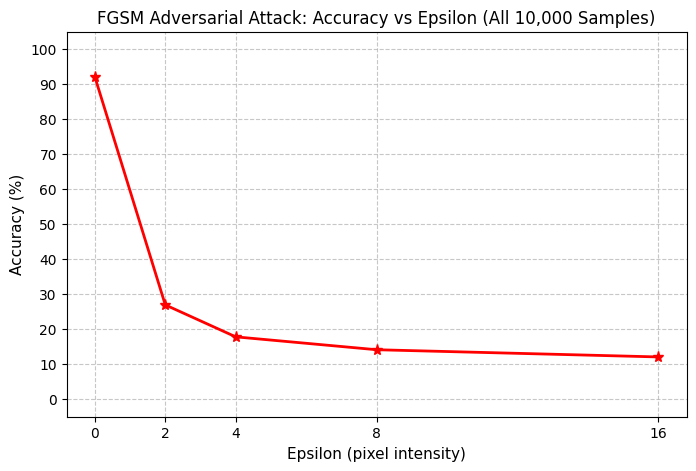

In [ ]:
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# Run the Attack for different epsilon values
epsilons = [0, 2/255, 4/255, 8/255, 16/255]
accuracies = []
all_examples = {}
model.eval()

print("Running attacks across different epsilons...")
for eps in epsilons:
    acc, ex = test_fgsm(model, device, test_loader, eps)
    accuracies.append(acc)
    all_examples[eps] = ex

# graphs
plt.figure(figsize=(8, 5))
eps_scaled = [int(round(e * 255)) for e in epsilons]

plt.plot(eps_scaled, accuracies, "*-", color='red', linewidth=2, markersize=8)
plt.title("FGSM Adversarial Attack: Accuracy vs Epsilon (All 10,000 Samples)", fontsize=12)
plt.xlabel("Epsilon (pixel intensity)", fontsize=11)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.xticks(eps_scaled)
plt.yticks(range(0, 105, 10))
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 105)
plt.show()

Searching for 2 successful adversarial examples randomly...

[Sample 1] Found! Index in dataset: 9459
Original: airplane (99.99%) -> Adversarial: bird (76.45%)


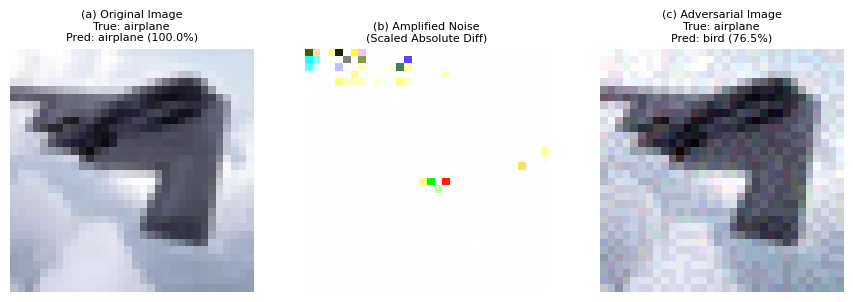


[Sample 2] Found! Index in dataset: 7270
Original: truck (100.00%) -> Adversarial: bird (76.90%)


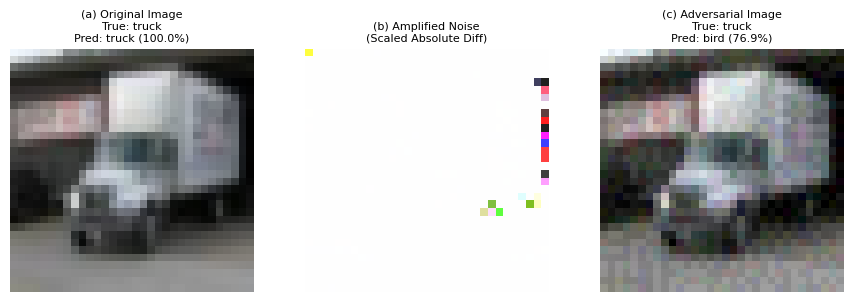

In [ ]:
def run_and_visualize_attack_multiple(model, dataset, epsilon=2/255, num_samples=2, device='cpu'):
    model.eval()
    found_count = 0

    print(f"Searching for {num_samples} successful adversarial examples randomly...")

    # Shuffle dataset indices to get different samples every execution
    shuffled_indices = np.random.permutation(len(dataset))

    for idx in shuffled_indices:
        if found_count >= num_samples:
            break

        img, label = dataset[idx]

        # Add batch dimension and move to device
        img_tensor = img.unsqueeze(0).to(device)
        label_tensor = torch.tensor([label]).to(device)

        # Enable gradient tracking on input image
        img_tensor.requires_grad = True

        # Forward pass on clean image
        output = model(img_tensor)
        init_pred = output.max(1, keepdim=True)[1]

        # Only attack if the clean model predicted it correctly
        if init_pred.item() != label:
            continue

        # Calculate gradient
        loss = F.cross_entropy(output, label_tensor)
        model.zero_grad()
        loss.backward()

        data_grad = img_tensor.grad.data

        # Generate adversarial perturbation
        perturbed_img = fgsm_attack(img_tensor, epsilon, data_grad)

        # Predict on adversarial image
        output_adv = model(perturbed_img)
        adv_pred = output_adv.max(1, keepdim=True)[1]

        # If the model is successfully fooled
        if adv_pred.item() != label:
            found_count += 1

            # Calculate confidences
            prob_clean = F.softmax(output, dim=1)
            prob_adv = F.softmax(output_adv, dim=1)

            clean_conf = prob_clean[0][label].item() * 100
            adv_conf = prob_adv[0][adv_pred.item()].item() * 100

            print(f"\n[Sample {found_count}] Found! Index in dataset: {idx}")
            print(f"Original: {cifar10_classes[label]} ({clean_conf:.2f}%) -> Adversarial: {cifar10_classes[adv_pred.item()]} ({adv_conf:.2f}%)")

            # Convert to numpy for plotting
            orig_np = img_tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
            adv_np = perturbed_img.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

            # Extract and scale the added noise
            noise_np = np.abs(adv_np - orig_np)
            if noise_np.max() > 0:
                noise_np = noise_np / noise_np.max()

            # Smaller and tighter figure layout (9x3 instead of 15x5)
            fig, axes = plt.subplots(1, 3, figsize=(9, 3))

            # (a) Original Image
            axes[0].imshow(orig_np)
            axes[0].set_title(f"(a) Original Image\nTrue: {cifar10_classes[label]}\nPred: {cifar10_classes[label]} ({clean_conf:.1f}%)", fontsize=8)
            axes[0].axis('off')

            # (b) Amplified Noise
            axes[1].imshow(noise_np)
            axes[1].set_title("(b) Amplified Noise\n(Scaled Absolute Diff)", fontsize=8)
            axes[1].axis('off')

            # (c) Adversarial Image
            axes[2].imshow(adv_np)
            axes[2].set_title(f"(c) Adversarial Image\nTrue: {cifar10_classes[label]}\nPred: {cifar10_classes[adv_pred.item()]} ({adv_conf:.1f}%)", fontsize=8)
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

    if found_count < num_samples:
        print(f"Only found {found_count} successful samples under epsilon={epsilon}.")

# Run visualization with standard budget (8/255) for 2 random samples
run_and_visualize_attack_multiple(model, test_set, epsilon=8/255, num_samples=2, device=device)

### 2. PGD Attack
using
$x^0 = \text{clip}_{[0, 1]} (x + \delta)$

$x^{t+1} = \text{clip}_{[0, 1]} \left( \text{clip}_{[x - \epsilon, x + \epsilon]} \left( x^t + \alpha \cdot \text{sign}(\nabla_{x^t} L(\theta, x^t, y)) \right) \right)$

In [ ]:
def pgd_attack(model, device, x, y, epsilon, alpha, num_steps=20):
    if epsilon == 0:
        return x.clone().detach()

    # Start PGD with a random noise to get x_0
    x_adv = x.clone().detach() + torch.empty_like(x).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    for _ in range(num_steps):
        x_adv.requires_grad = True
        outputs = model(x_adv)
        loss = F.cross_entropy(outputs, y)

        model.zero_grad()
        loss.backward()

        # Step in the direction of gradient sign
        gradient = x_adv.grad.data
        x_adv = x_adv.detach() + alpha * gradient.sign()

        # Clip to epsilon-ball around original x
        eta = torch.clamp(x_adv - x, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x + eta, min=0.0, max=1.0).detach()

    return x_adv

In [ ]:
def test_pgd(model, device, test_loader, epsilon, alpha, num_steps=20):
    model.eval()
    correct = 0
    total_images = 0

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        total_images += data.size(0)
        # Attack
        perturbed_data = pgd_attack(model, device, data, target, epsilon, epsilon/4, num_steps)

        # 3. Check on the model
        with torch.no_grad():
            output_adv = model(perturbed_data)
            final_pred = output_adv.max(1, keepdim=True)[1].squeeze(1)

        # Count how many successfully resisted the attack
        correct += (final_pred == target).sum().item()

    final_acc = (correct / float(total_images)) * 100 if total_images > 0 else 0
    eps_scaled = int(round(epsilon * 255))
    print(f"PGD Epsilon: {eps_scaled:2d}/255\tTest Accuracy = {correct:4d} / {total_images:4d} = {final_acc:.2f}%")

    return final_acc, []

Running PGD attacks across different epsilons...
PGD Epsilon:  0/255	Test Accuracy = 9212 / 10000 = 92.12%
PGD Epsilon:  2/255	Test Accuracy =   63 / 10000 = 0.63%
PGD Epsilon:  4/255	Test Accuracy =    0 / 10000 = 0.00%
PGD Epsilon:  8/255	Test Accuracy =    0 / 10000 = 0.00%
PGD Epsilon: 16/255	Test Accuracy =    0 / 10000 = 0.00%


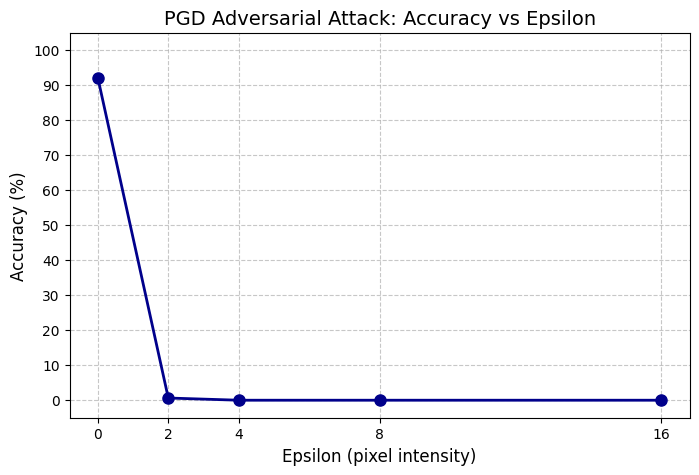

In [ ]:
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

epsilons = [0, 2/255, 4/255, 8/255, 16/255]
pgd_accuracies = []
model.eval()
print("Running PGD attacks across different epsilons...")
for eps in epsilons:
    acc, _ = test_pgd(model, device, test_loader, epsilon=eps, alpha=eps/4, num_steps=20)
    pgd_accuracies.append(acc)

# Graph
plt.figure(figsize=(8, 5))
eps_scaled = [int(round(e * 255)) for e in epsilons]

plt.plot(eps_scaled, pgd_accuracies, "o-", color='darkblue', linewidth=2, markersize=8)
plt.title("PGD Adversarial Attack: Accuracy vs Epsilon", fontsize=14)
plt.xlabel("Epsilon (pixel intensity)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(eps_scaled)
plt.yticks(range(0, 105, 10))
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-5, 105)

plt.show()

Searching for 2 successful PGD adversarial examples...

[PGD Sample 1] Found! Index in dataset: 4104
Original: airplane (100.00%) -> Adversarial: cat (100.00%)


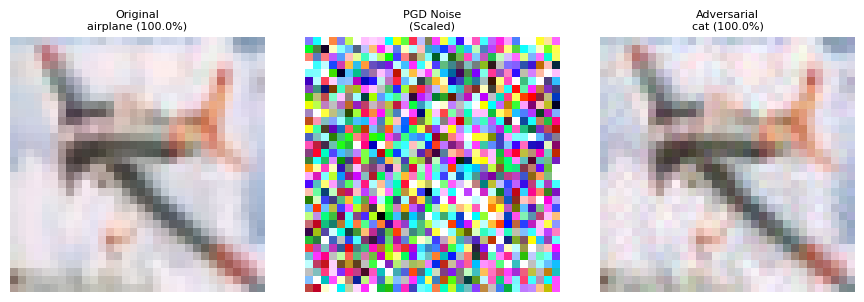


[PGD Sample 2] Found! Index in dataset: 46
Original: cat (99.81%) -> Adversarial: bird (100.00%)


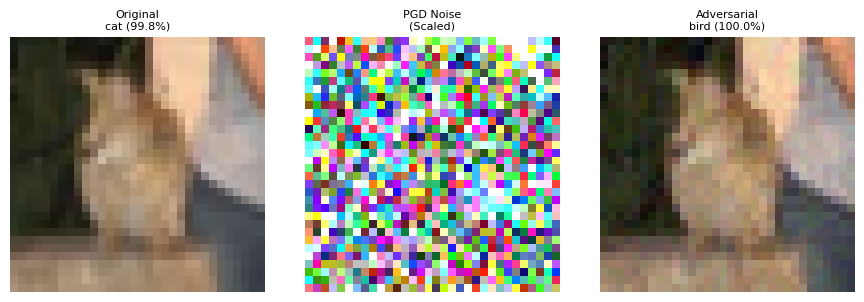

In [ ]:
def run_and_visualize_pgd_multiple(model, dataset, epsilon=8/255, alpha=2/255, num_steps=10, num_samples=2, device='cpu'):
    model.eval()
    found_count = 0
    cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    print(f"Searching for {num_samples} successful PGD adversarial examples...")

    # Randomly shuffle indices
    shuffled_indices = np.random.permutation(len(dataset))

    for idx in shuffled_indices:
        if found_count >= num_samples:
            break

        img, label = dataset[idx]

        # Prepare tensors
        img_tensor = img.unsqueeze(0).to(device)
        label_tensor = torch.tensor([label]).to(device)

        # Original prediction
        with torch.no_grad():
            output = model(img_tensor)
            init_pred = output.max(1, keepdim=True)[1]

        # Skip if model was already wrong on clean image
        if init_pred.item() != label:
            continue

        # Attack
        perturbed_img = pgd_attack(model, device, img_tensor, label_tensor, epsilon, epsilon/4, num_steps)

        # Adversarial prediction
        with torch.no_grad():
            output_adv = model(perturbed_img)
            adv_pred = output_adv.max(1, keepdim=True)[1]

        # Check if successful
        if adv_pred.item() != label:
            found_count += 1

            # Confidences calculation
            prob_clean = F.softmax(output, dim=1)
            prob_adv = F.softmax(output_adv, dim=1)
            clean_conf = prob_clean[0][label].item() * 100
            adv_conf = prob_adv[0][adv_pred.item()].item() * 100

            print(f"\n[PGD Sample {found_count}] Found! Index in dataset: {idx}")
            print(f"Original: {cifar10_classes[label]} ({clean_conf:.2f}%) -> Adversarial: {cifar10_classes[adv_pred.item()]} ({adv_conf:.2f}%)")

            # Prepare for plotting
            orig_np = img_tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
            adv_np = perturbed_img.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()

            # Noise extraction and scaling
            noise_np = np.abs(adv_np - orig_np)
            if noise_np.max() > 0:
                noise_np = noise_np / noise_np.max()

            # Plot results
            fig, axes = plt.subplots(1, 3, figsize=(9, 3))

            axes[0].imshow(orig_np)
            axes[0].set_title(f"Original\n{cifar10_classes[label]} ({clean_conf:.1f}%)", fontsize=8)
            axes[0].axis('off')

            axes[1].imshow(noise_np)
            axes[1].set_title("PGD Noise\n(Scaled)", fontsize=8)
            axes[1].axis('off')

            axes[2].imshow(adv_np)
            axes[2].set_title(f"Adversarial\n{cifar10_classes[adv_pred.item()]} ({adv_conf:.1f}%)", fontsize=8)
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

    if found_count < num_samples:
        print(f"Only found {found_count} successful samples under epsilon={epsilon}.")

# Run PGD visualization with epsilon=8/255, alpha=2/255 and 10 steps
run_and_visualize_pgd_multiple(model, test_set, epsilon=8/255, alpha=2/255, num_steps=10, num_samples=2, device=device)

### 3. DeepFool

In [ ]:
def plot_adversarial_examples(adv_examples, class_names=None):
    if not adv_examples:
        print("No adversarial examples were captured to plot.")
        return

    num_examples = len(adv_examples)
    fig, axes = plt.subplots(num_examples, 3, figsize=(7, 2.2 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, example in enumerate(adv_examples):
        # unpack stored example tuple
        clean_tensor, adv_tensor, delta_tensor, clean_pred, adv_pred, clean_conf, adv_conf = example

        # convert PyTorch (C, H, W) -> Matplotlib (H, W, C)
        clean_np = clean_tensor.permute(1, 2, 0).numpy()
        adv_np = adv_tensor.permute(1, 2, 0).numpy()
        noise_np = delta_tensor.abs().permute(1, 2, 0).numpy()

        # clip images to valid RGB display range [0, 1]
        clean_np = np.clip(clean_np, 0, 1)
        adv_np = np.clip(adv_np, 0, 1)

        # normalize noise map to [0, 1] for visualization clarity
        if noise_np.max() > 0:
            noise_np = noise_np / noise_np.max()

        # labels
        clean_label = class_names[clean_pred] if class_names else f"Class {clean_pred}"
        adv_label = class_names[adv_pred] if class_names else f"Class {adv_pred}"

        # Column 1: Original Image
        axes[i, 0].imshow(clean_np, interpolation='nearest')
        axes[i, 0].set_title(
            f"Original: {clean_label}\nConf: {clean_conf:.1f}%",
            fontsize=9,
            fontweight='bold'
        )
        axes[i, 0].axis('off')

        # Column 2: Amplified Noise Map
        axes[i, 1].imshow(noise_np, interpolation='nearest')
        axes[i, 1].set_title("Perturbation (Amplified)", fontsize=9)
        axes[i, 1].axis('off')

        # Column 3: Adversarial Image
        axes[i, 2].imshow(adv_np, interpolation='nearest')
        axes[i, 2].set_title(
            f"Adversarial: {adv_label}\nConf: {adv_conf:.1f}%",
            fontsize=9,
            color='red',
            fontweight='bold'
        )
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def deepfool_attack(model, image, num_classes=10, max_iter=50, overshoot=0.02):
    model.eval()

    # create a fresh copy of the image
    x_i = image.clone().detach().requires_grad_(True)

    logits = model(x_i)
    init_pred = logits.argmax(dim=1).item()

    current_pred = init_pred
    loop_counter = 0

    while current_pred == init_pred and loop_counter < max_iter:
        if x_i.grad is not None:
            x_i.grad.zero_()

        # gradient for the initial predicted class
        logits[0, init_pred].backward(retain_graph=True)
        grad_orig = x_i.grad.data.clone()

        w_min = None
        d_min = float('inf')

        # find the closest decision boundary among all other classes
        for k in range(num_classes):
            if k == init_pred: continue

            x_i.grad.zero_()
            logits[0, k].backward(retain_graph=True)
            grad_k = x_i.grad.data.clone()

            w_k = grad_k - grad_orig
            f_k = (logits[0, k] - logits[0, init_pred]).item()
            norm_w = torch.norm(w_k).item()
            d_k = abs(f_k) / (norm_w + 1e-8)

            if d_k < d_min:
                d_min = d_k
                w_min = w_k

        # compute perturbation step towards closest boundary
        norm_w_min = torch.norm(w_min).item()
        r_i = (d_min / (norm_w_min + 1e-8)) * w_min

        # update image with overshoot and clamp
        x_i = (x_i + (1 + overshoot) * r_i).clamp(0, 1).detach().requires_grad_(True)

        # we re-evaluate class prediction for next iteration check
        logits = model(x_i)
        current_pred = logits.argmax(dim=1).item()
        loop_counter += 1

    # return final adversarial image and total perturbation delta
    delta = x_i - image
    return x_i.detach(), delta.detach()

In [ ]:
def test_deepfool(model, device, test_loader, num_classes=10, max_iter=50, overshoot=0.02, max_samples=500):
    model.eval()

    correct_clean = 0
    correct_adv = 0
    total_evaluated = 0
    l2_norms = []
    adv_examples = []

    print(f"Starting DeepFool Attack Evaluation on {max_samples} samples...")
    print(f"Hyperparameters: num_classes={num_classes} | max_iter={max_iter} | overshoot={overshoot}\n")

    # wrap test_loader with tqdm progress bar
    pbar = tqdm(test_loader, desc="DeepFool Progress", total=max_samples or len(test_loader))

    for data, target in pbar:
        if max_samples and total_evaluated >= max_samples:
            break

        total_evaluated += 1
        data, target = data.to(device), target.to(device)

        # verify model predicts the clean image correctly
        with torch.no_grad():
            clean_output = model(data)
            clean_pred = clean_output.argmax(dim=1).item()

        # skip samples already misclassified by the clean model
        if clean_pred != target.item():
            continue

        correct_clean += 1

        # execute DeepFool attack on the single image
        adv_img, delta = deepfool_attack(
            model,
            data,
            num_classes=num_classes,
            max_iter=max_iter,
            overshoot=overshoot
        )

        # evaluate prediction on adversarial image
        with torch.no_grad():
            adv_output = model(adv_img)
            adv_pred = adv_output.argmax(dim=1).item()

        # calculate L2 norm of the perturbation
        l2_norm = torch.norm(delta).item()

        # track statistics
        if adv_pred == target.item():
            correct_adv += 1
        else:
            l2_norms.append(l2_norm)

            clean_probs = torch.softmax(clean_output, dim=1)
            adv_probs = torch.softmax(adv_output, dim=1)

            clean_conf = clean_probs[0, target.item()].item() * 100
            adv_conf = adv_probs[0, adv_pred].item() * 100

            # store up to 5 examples for visualization
            if len(adv_examples) < 5:
                adv_examples.append((
                    data.squeeze(0).cpu(),
                    adv_img.squeeze(0).cpu(),
                    delta.squeeze(0).cpu(),
                    target.item(),
                    adv_pred,
                    clean_conf,
                    adv_conf
                ))

    # final metrics
    adv_acc = (correct_adv / total_evaluated) * 100 if total_evaluated > 0 else 0
    attack_success_rate = (correct_clean - correct_adv) / correct_clean * 100 if correct_clean > 0 else 0
    avg_l2 = sum(l2_norms) / len(l2_norms) if len(l2_norms) > 0 else 0.0

    print("\n" + "=" * 50)
    print("            DEEPFOOL ATTACK RESULTS            ")
    print("=" * 50)
    print(f"Total Samples Evaluated:   {total_evaluated}")
    print(f"Robust Accuracy:          {adv_acc:.2f}%")
    print(f"Attack Success Rate:      {attack_success_rate:.2f}%")
    print(f"Average L2 Perturbation:  {avg_l2:.4f}")
    print("=" * 50)

    return adv_acc, avg_l2, adv_examples

Starting DeepFool Attack Evaluation on 500 samples...
Hyperparameters: num_classes=10 | max_iter=50 | overshoot=0.02



DeepFool Progress:   0%|          | 0/500 [00:00<?, ?it/s]


            DEEPFOOL ATTACK RESULTS            
Total Samples Evaluated:   500
Robust Accuracy:          5.00%
Attack Success Rate:      94.55%
Average L2 Perturbation:  0.1179


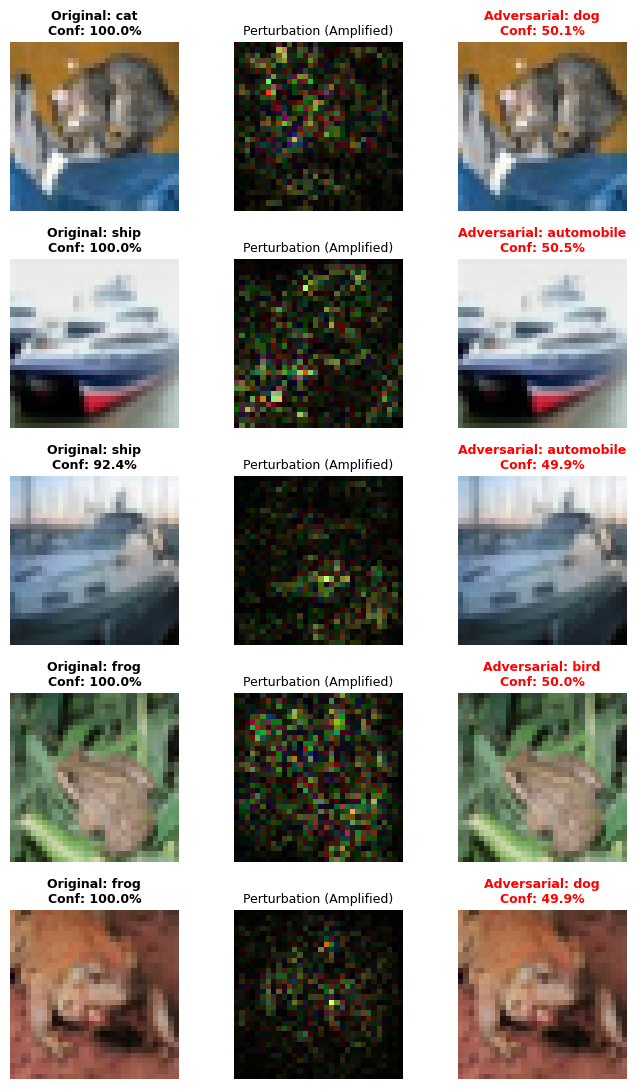

In [ ]:
# batch size must be 1 for single-image optimization
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

# results
acc, avg_l2, adv_examples = test_deepfool(
    model,
    device,
    test_loader,
    num_classes=10,
    max_iter=50,
    overshoot=0.02,
    max_samples=500
)

# plotting
plot_adversarial_examples(adv_examples, class_names=cifar10_classes)


### 4. C&W Using L2

In [ ]:
def cw_l2_attack(model, image, target_class, c=1.0, kappa=0, max_iter=100, lr=0.01):
    model.eval()

    # scale image slightly away from exact 0/1 to avoid atanh +/-inf
    x_safe = torch.clamp(image, 1e-6, 1.0 - 1e-6)
    w = torch.atanh(2.0 * x_safe - 1.0).clone().detach().requires_grad_(True)

    optimizer = optim.Adam([w], lr=lr)

    best_l2 = float('inf')
    best_adv_img = image.clone().detach()

    for i in range(max_iter):
        # clear gradients from previous iteration
        optimizer.zero_grad()

        # reconstruct image from w-space
        adv_image = (torch.tanh(w) + 1.0) / 2.0

        # compute L2 distance loss
        delta = adv_image - image
        l2_loss = torch.sum(delta ** 2)

        # forward pass
        logits = model(adv_image)
        logit_target = logits[0, target_class]

        # mask out target class with -inf to find max non-target logit
        logits_clone = logits.clone()
        logits_clone[0, target_class] = -float('inf')
        other_max_logit = logits_clone.max(dim=1)[0]

        # compute loss f(x') and total loss
        f_loss = torch.clamp(logit_target - other_max_logit, min=-kappa)
        total_loss = l2_loss + c * f_loss

        # backpropagate and take Adam step
        total_loss.backward()
        optimizer.step()

        # check if previous iteration succeeded and track the best result
        pred = logits.argmax(dim=1).item()
        current_l2 = torch.norm(delta).item()

        if pred != target_class and current_l2 < best_l2:
            best_l2 = current_l2
            best_adv_img = adv_image.detach().clone()

    delta = best_adv_img - image
    return best_adv_img, delta.detach()

In [ ]:
def test_cw_l2(model, device, test_loader, c=1.0, kappa=0, max_iter=100, lr=0.01, max_samples=500):
    model.eval()

    correct_clean = 0
    correct_adv = 0
    total_evaluated = 0
    l2_norms = []
    adv_examples = []

    print(f"Starting C&W L2 Attack Evaluation on {max_samples} samples...")
    print(f"Hyperparameters: c={c} | kappa={kappa} | max_iter={max_iter} | lr={lr}\n")

    # wrap test_loader with tqdm progress bar
    pbar = tqdm(test_loader, desc="C&W L2 Progress", total=max_samples or len(test_loader))

    for data, target in pbar:
        if total_evaluated >= max_samples:
            break

        total_evaluated += 1
        data, target = data.to(device), target.to(device)

        # verify model predicts the clean image correctly
        with torch.no_grad():
            clean_output = model(data)
            clean_pred = clean_output.argmax(dim=1).item()

        # skip samples already misclassified by the clean model
        if clean_pred != target.item():
            continue

        correct_clean += 1

        # execute C&W L2 attack on the single image
        adv_img, delta = cw_l2_attack(
            model,
            data,
            target_class=target.item(),
            c=c,
            kappa=kappa,
            max_iter=max_iter,
            lr=lr
        )

        # evaluate prediction on adversarial image
        with torch.no_grad():
            adv_output = model(adv_img)
            adv_pred = adv_output.argmax(dim=1).item()

        # calculate L2 norm of the perturbation
        l2_norm = torch.norm(delta).item()

        # track statistics
        if adv_pred == target.item():
            correct_adv += 1
        else:
            l2_norms.append(l2_norm)

            clean_probs = torch.softmax(clean_output, dim=1)
            adv_probs = torch.softmax(adv_output, dim=1)

            clean_conf = clean_probs[0, target.item()].item() * 100
            adv_conf = adv_probs[0, adv_pred].item() * 100

            # store up to 5 examples for visualization
            if len(adv_examples) < 5:
                adv_examples.append((
                    data.squeeze(0).cpu(),
                    adv_img.squeeze(0).cpu(),
                    delta.squeeze(0).cpu(),
                    target.item(),
                    adv_pred,
                    clean_conf,
                    adv_conf
                ))

    # final metrics
    adv_acc = (correct_adv / total_evaluated) * 100 if total_evaluated > 0 else 0
    attack_success_rate = (correct_clean - correct_adv) / correct_clean * 100 if correct_clean > 0 else 0
    avg_l2 = sum(l2_norms) / len(l2_norms) if len(l2_norms) > 0 else 0.0

    print("\n" + "=" * 50)
    print("            C&W L2 ATTACK RESULTS            ")
    print("=" * 50)
    print(f"Total Samples Evaluated:   {total_evaluated}")
    print(f"Robust Accuracy:          {adv_acc:.2f}%")
    print(f"Attack Success Rate:      {attack_success_rate:.2f}%")
    print(f"Average L2 Perturbation:  {avg_l2:.4f}")
    print("=" * 50)

    return adv_acc, avg_l2, adv_examples

Starting C&W L2 Attack Evaluation on 500 samples...
Hyperparameters: c=1.0 | kappa=0 | max_iter=100 | lr=0.01



C&W L2 Progress:   0%|          | 0/500 [00:00<?, ?it/s]


            C&W L2 ATTACK RESULTS            
Total Samples Evaluated:   500
Robust Accuracy:          0.00%
Attack Success Rate:      100.00%
Average L2 Perturbation:  0.1466


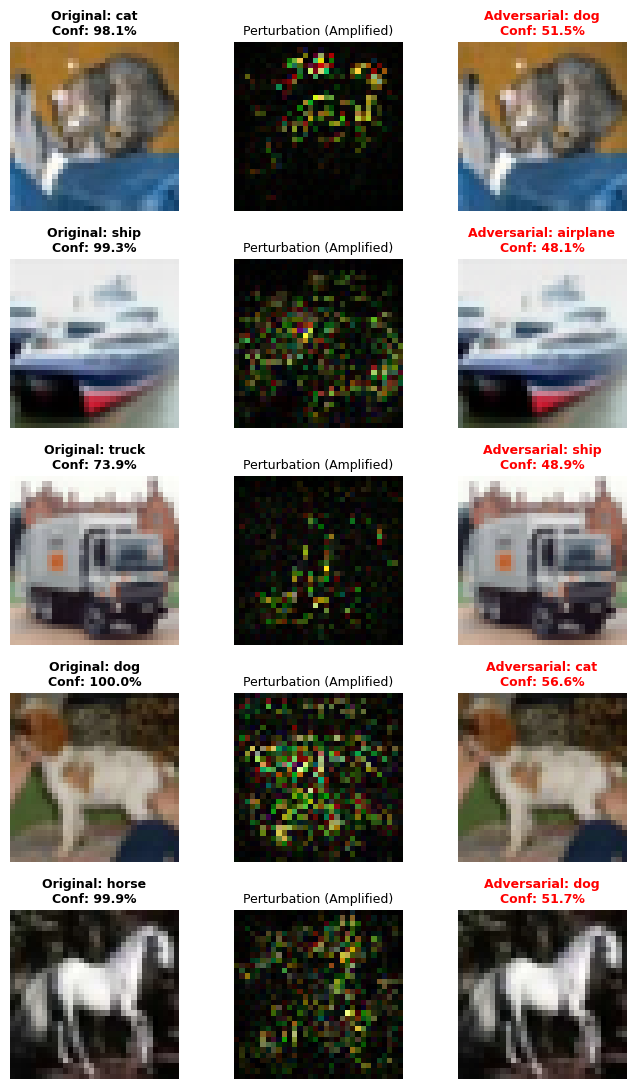

In [ ]:
# batch size must be 1 for single-image optimization
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

# results
adv_acc, avg_l2, adv_examples = test_cw_l2(
    resnet20_base,
    device,
    test_loader,
    c=1.0,
    kappa=0,
    max_iter=100,
    lr=0.01,
    max_samples=500
)

# plotting
plot_adversarial_examples(adv_examples, class_names=cifar10_classes)

## Defense Mechanisms

### 1. Randomized Smoothing

In [ ]:
# path for the noise-fine-tuned model backup
smoothed_model_path = '/content/drive/MyDrive/CIFAR10_Backup/resnet20_smoothed_sigma025.pth'

def get_or_train_smoothed_model(base_model, train_loader, device, sigma=0.25, epochs=5):
    # check if the fine-tuned model already exists in Google Drive
    if os.path.exists(smoothed_model_path):
        print(f"Loading existing noise-fine-tuned model from: {smoothed_model_path}")
        smoothed_model = torch.load(smoothed_model_path, map_location=device, weights_only=False)
        print("Model loaded successfully!")
        return smoothed_model

    # if fine-tuning is needed, create a DEEP COPY first!!!
    print(f"No saved model found. Creating a model copy and fine-tuning for {epochs} epochs (sigma={sigma})...\n")

    model_to_tune = copy.deepcopy(base_model).to(device)
    model_to_tune.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_to_tune.parameters(), lr=0.001)

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            # add gaussian noise
            noise = torch.randn_like(data) * sigma
            noisy_data = torch.clamp(data + noise, 0.0, 1.0)

            optimizer.zero_grad()
            outputs = model_to_tune(noisy_data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += target.size(0)

        epoch_loss = running_loss / total
        epoch_acc = (correct / total) * 100
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Noisy Train Acc: {epoch_acc:.2f}%")

    # save to Google Drive for future runs
    try:
        os.makedirs(os.path.dirname(smoothed_model_path), exist_ok=True)
        torch.save(model_to_tune, smoothed_model_path)
        print(f"\nFine-tuned model successfully saved to Drive: {smoothed_model_path}")
    except Exception as e:
        print(f"Warning: Could not save model to Drive: {e}")

    return model_to_tune

In [ ]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

# execute dynamic load/train
resnet20_smoothed = get_or_train_smoothed_model(
    base_model=model,
    train_loader=train_loader,
    device=device,
    sigma=0.25,
    epochs=5
)

Loading existing noise-fine-tuned model from: /content/drive/MyDrive/CIFAR10_Backup/resnet20_smoothed_sigma025.pth
Model loaded successfully!


In [ ]:
def predict_smooth(model, image, sigma=0.25, num_noised_samples=100, num_classes=10, eval_batch_size=32):
    model.eval()

    # repeat image N times and add gaussian noise
    x_repeated = image.repeat(num_noised_samples, 1, 1, 1)     # shape: (N, C, H, W)
    noise = torch.randn_like(x_repeated) * sigma
    x_noisy = torch.clamp(x_repeated + noise, 0.0, 1.0)

    all_preds = []
    with torch.no_grad():
        for start_idx in range(0, num_noised_samples, eval_batch_size):
            end_idx = min(start_idx + eval_batch_size, num_noised_samples)
            batch_noisy = x_noisy[start_idx:end_idx]

            logits = model(batch_noisy)
            preds = logits.argmax(dim=1)
            all_preds.append(preds)

    all_preds = torch.cat(all_preds)

    # count frequency of each predicted class
    counts = torch.bincount(all_preds, minlength=num_classes)
    # find class with maximum votes and calculate confidence ratio
    top_class = counts.argmax().item()
    top_count = counts[top_class].item()
    p_a = top_count / num_noised_samples

    return top_class, p_a

In [ ]:
def evaluate_smoothing_on_samples(
    model,
    eval_samples,
    device,
    sigma=0.25,
    num_noised_samples=100,
    num_classes=10,
    eval_name="Clean Data"
):
    model.eval()
    correct_count = 0
    total_samples = len(eval_samples)

    if total_samples == 0:
        print("No samples provided for evaluation.")
        return 0.0

    print(f"--- Running Randomized Smoothing Evaluation: [{eval_name}] ---")
    print(f"Total Samples: {total_samples} | sigma={sigma} | N={num_noised_samples}\n")

    pbar = tqdm(eval_samples, desc=f"Smoothing ({eval_name})")

    for img_tensor, label in pbar:
        # ensure image is on correct device and has batch dimension (1, C, H, W)
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # predict using Randomized Smoothing
        smooth_pred, p_a = predict_smooth(
            model=model,
            image=img_tensor,
            sigma=sigma,
            num_noised_samples=num_noised_samples,
            num_classes=num_classes
        )

        if smooth_pred == label:
            correct_count += 1

    robust_accuracy = (correct_count / total_samples) * 100

    print("\n" + "=" * 55)
    print(f"   RANDOMIZED SMOOTHING RESULTS: [{eval_name.upper()}]   ")
    print("=" * 55)
    print(f"Evaluated Samples             : {total_samples}")
    print(f"Robust Accuracy               : {robust_accuracy:.2f}% ({correct_count}/{total_samples})")
    print("=" * 55 + "\n")

    return robust_accuracy

#### 1. Clean Baseline Dataset

In [ ]:
# using batch size = 1
test_loader = DataLoader(test_set, batch_size=1, shuffle=False)

clean_samples = []
for data, target in test_loader:
    if len(clean_samples) >= 500: break
    clean_samples.append((data.clone(), target.item()))

# evaluate
clean_acc = evaluate_smoothing_on_samples(
    resnet20_smoothed, clean_samples, device, eval_name="Clean Data"
)

--- Running Randomized Smoothing Evaluation: [Clean Data] ---
Total Samples: 500 | sigma=0.25 | N=100



Smoothing (Clean Data):   0%|          | 0/500 [00:00<?, ?it/s]


   RANDOMIZED SMOOTHING RESULTS: [CLEAN DATA]   
Evaluated Samples             : 500
Robust Accuracy               : 76.60% (383/500)



#### 2. FGSM Dataset

In [ ]:
fgsm_samples = []
model.eval()

epsilon = 8/255

for data, target in test_loader:
    if len(fgsm_samples) >= 500: break
    data, target = data.to(device), target.to(device)

    # enable grad to compute data_grad
    data.requires_grad = True
    output = model(data)

    loss = F.cross_entropy(output, target)
    model.zero_grad()
    loss.backward()

    # we call our FGSM function
    adv_img = fgsm_attack(data, epsilon=epsilon, data_grad=data.grad.data)
    fgsm_samples.append((adv_img.detach().cpu(), target.item()))

# evaluate
fgsm_acc = evaluate_smoothing_on_samples(
    resnet20_smoothed, fgsm_samples, device, eval_name=f"FGSM (eps={epsilon:.2f})"
)

--- Running Randomized Smoothing Evaluation: [FGSM (eps=0.03)] ---
Total Samples: 500 | sigma=0.25 | N=100



Smoothing (FGSM (eps=0.03)):   0%|          | 0/500 [00:00<?, ?it/s]


   RANDOMIZED SMOOTHING RESULTS: [FGSM (EPS=0.03)]   
Evaluated Samples             : 500
Robust Accuracy               : 74.00% (370/500)



#### 3. PGD Dataset

In [ ]:
pgd_samples = []
model.eval()

epsilon=8/255
alpha=epsilon/4
num_steps=10

for data, target in test_loader:
    if len(pgd_samples) >= 500: break
    data, target = data.to(device), target.to(device)

    # call our PGD function
    adv_img = pgd_attack(model, device, data, target, epsilon=epsilon, alpha=alpha, num_steps=num_steps)
    pgd_samples.append((adv_img.detach().cpu(), target.item()))

# evaluate
pgd_acc = evaluate_smoothing_on_samples(
    resnet20_smoothed, pgd_samples, device, eval_name=f"PGD-10 (epsilon={epsilon:.2f}, alpha={alpha:.2f}, num_steps={num_steps})"
)

--- Running Randomized Smoothing Evaluation: [PGD-10 (epsilon=0.03, alpha=0.01, num_steps=10)] ---
Total Samples: 500 | sigma=0.25 | N=100



Smoothing (PGD-10 (epsilon=0.03, alpha=0.01, num_steps=10)):   0%|          | 0/500 [00:00<?, ?it/s]


   RANDOMIZED SMOOTHING RESULTS: [PGD-10 (EPSILON=0.03, ALPHA=0.01, NUM_STEPS=10)]   
Evaluated Samples             : 500
Robust Accuracy               : 74.60% (373/500)



#### 4. DeepFool Dataset

In [ ]:
deepfool_samples = []
model.eval()

max_iter=50
overshoot=0.02

for data, target in test_loader:
    if len(deepfool_samples) >= 500: break
    data, target = data.to(device), target.to(device)

    # call our DeepFool function
    adv_img, _ = deepfool_attack(model, data, num_classes=10, max_iter=max_iter, overshoot=overshoot)
    deepfool_samples.append((adv_img.detach().cpu(), target.item()))

# evaluate
deepfool_acc = evaluate_smoothing_on_samples(
    resnet20_smoothed, deepfool_samples, device, eval_name=f"DeepFool (max_iter={max_iter}, overshoot={overshoot})"
)

--- Running Randomized Smoothing Evaluation: [DeepFool (max_iter=50, overshoot=0.02)] ---
Total Samples: 500 | sigma=0.25 | N=100



Smoothing (DeepFool (max_iter=50, overshoot=0.02)):   0%|          | 0/500 [00:00<?, ?it/s]


   RANDOMIZED SMOOTHING RESULTS: [DEEPFOOL (MAX_ITER=50, OVERSHOOT=0.02)]   
Evaluated Samples             : 500
Robust Accuracy               : 76.60% (383/500)



#### 5. C&W L2 Dataset

In [ ]:
cw_l2_samples = []
model.eval()

c=1.0
kappa=0
max_iter=100
lr=0.01

for data, target in test_loader:
    if len(cw_l2_samples) >= 500: break
    data, target = data.to(device), target.to(device)

    # call our C&W L2 function
    adv_img, _ = cw_l2_attack(model, data, target_class=target.item(), c=c, kappa=kappa, max_iter=max_iter, lr=lr)
    cw_l2_samples.append((adv_img.detach().cpu(), target.item()))

# evaluate
cw_l2_acc = evaluate_smoothing_on_samples(
    resnet20_smoothed, cw_l2_samples, device, eval_name=f"C&W L2 (max_iter={max_iter}, overshoot={overshoot})"
)

--- Running Randomized Smoothing Evaluation: [C&W L2 (max_iter=100, overshoot=0.02)] ---
Total Samples: 500 | sigma=0.25 | N=100



Smoothing (C&W L2 (max_iter=100, overshoot=0.02)):   0%|          | 0/500 [00:00<?, ?it/s]


   RANDOMIZED SMOOTHING RESULTS: [C&W L2 (MAX_ITER=100, OVERSHOOT=0.02)]   
Evaluated Samples             : 500
Robust Accuracy               : 76.00% (380/500)



### 2. Adversarial Training

In [ ]:
# path to adversarial trained backup
adv_model_path = '/content/drive/MyDrive/CIFAR10_Backup/resnet20_adv_trained.pth'

def get_or_train_adv_model(base_model, train_loader, device, epsilon=8/255, alpha=2/255, iters=10, epochs=10):
    # check if it exists on drive
    if os.path.exists(adv_model_path):
        print(f"Loading existing adv-trained model from: {adv_model_path}")
        adv_model = torch.load(adv_model_path, map_location=device, weights_only=False)
        return adv_model

    # othervise train it with adv data
    print(f"No saved model found. Adversarial training for {epochs} epochs...\n")
    model_to_tune = copy.deepcopy(base_model).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_to_tune.parameters(), lr=0.001)

    for epoch in range(epochs):
        model_to_tune.train()
        running_loss, correct, total = 0.0, 0, 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            model_to_tune.eval()
            adv_data = data.clone().detach()
            adv_data.requires_grad = True

            for _ in range(iters):
                outputs = model_to_tune(adv_data)
                loss = criterion(outputs, target)
                model_to_tune.zero_grad()
                loss.backward()
                with torch.no_grad():
                    adv_data = adv_data + alpha * adv_data.grad.sign()
                    eta = torch.clamp(adv_data - data, min=-epsilon, max=epsilon)
                    adv_data = torch.clamp(data + eta, min=0.0, max=1.0)
                adv_data.requires_grad = True

            model_to_tune.train()
            optimizer.zero_grad()
            outputs = model_to_tune(adv_data.detach())
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            correct += (outputs.argmax(dim=1) == target).sum().item()
            total += target.size(0)

        print(f"Epoch [{epoch+1}/{epochs}] | Adv Loss: {running_loss/total:.4f} | Adv Train Acc: {(correct/total)*100:.2f}%")
    # save
    try:
        os.makedirs(os.path.dirname(adv_model_path), exist_ok=True)
        torch.save(model_to_tune, adv_model_path)
    except Exception as e:
        print(f"Warning: Could not save model: {e}")

    return model_to_tune

In [ ]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)

# execute dynamic load/train
resnet20_adv = get_or_train_adv_model(model, train_loader, device, epochs=10)

No saved model found. Adversarial training for 10 epochs...

Epoch [1/10] | Adv Loss: 2.1295 | Adv Train Acc: 24.63%
Epoch [2/10] | Adv Loss: 1.7584 | Adv Train Acc: 33.65%
Epoch [3/10] | Adv Loss: 1.6612 | Adv Train Acc: 36.91%
Epoch [4/10] | Adv Loss: 1.6000 | Adv Train Acc: 39.07%
Epoch [5/10] | Adv Loss: 1.5586 | Adv Train Acc: 40.66%
Epoch [6/10] | Adv Loss: 1.5268 | Adv Train Acc: 41.88%
Epoch [7/10] | Adv Loss: 1.4984 | Adv Train Acc: 43.04%
Epoch [8/10] | Adv Loss: 1.4736 | Adv Train Acc: 43.87%
Epoch [9/10] | Adv Loss: 1.4553 | Adv Train Acc: 44.66%
Epoch [10/10] | Adv Loss: 1.4355 | Adv Train Acc: 45.32%


In [ ]:
# find the max match
def predict_adv(model, image):
    model.eval()
    with torch.no_grad():
        logits = model(image)
        pred = logits.argmax(dim=1).item()
    return pred

In [ ]:
def evaluate_adv_on_samples(model, eval_samples, device, eval_name="Clean Data"):
    model.eval()
    correct_count = 0
    total_samples = len(eval_samples)

    if total_samples == 0:
        return 0.0

    print(f"--- Running Adversarial Training Evaluation: [{eval_name}] ---")
    pbar = tqdm(eval_samples, desc=f"Adv Training ({eval_name})")

    for img_tensor, label in pbar:
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # run the test
        pred = predict_adv(model=model, image=img_tensor)

        if pred == label:
            correct_count += 1

    robust_accuracy = (correct_count / total_samples) * 100

    print("\n" + "=" * 55)
    print(f"   ADVERSARIAL TRAINING RESULTS: [{eval_name.upper()}]   ")
    print("=" * 55)
    print(f"Robust Accuracy               : {robust_accuracy:.2f}% ({correct_count}/{total_samples})")
    print("=" * 55 + "\n")

    return robust_accuracy

#### 1. Clean Dataset

In [ ]:
adv_clean_acc = evaluate_adv_on_samples(
    resnet20_adv, clean_samples, device, eval_name="Clean Data"
)

--- Running Adversarial Training Evaluation: [Clean Data] ---


Adv Training (Clean Data):   0%|          | 0/500 [00:00<?, ?it/s]


   ADVERSARIAL TRAINING RESULTS: [CLEAN DATA]   
Robust Accuracy               : 69.20% (346/500)



#### 2. FGSM Dataset

In [ ]:
adv_fgsm_acc = evaluate_adv_on_samples(
    resnet20_adv, fgsm_samples, device, eval_name="FGSM"
)

--- Running Adversarial Training Evaluation: [FGSM] ---


Adv Training (FGSM):   0%|          | 0/500 [00:00<?, ?it/s]


   ADVERSARIAL TRAINING RESULTS: [FGSM]   
Robust Accuracy               : 68.20% (341/500)



#### 3. PGD Dataset

In [ ]:
adv_pgd_acc = evaluate_adv_on_samples(
    resnet20_adv, pgd_samples, device, eval_name="PGD-10"
)

--- Running Adversarial Training Evaluation: [PGD-10] ---


Adv Training (PGD-10):   0%|          | 0/500 [00:00<?, ?it/s]


   ADVERSARIAL TRAINING RESULTS: [PGD-10]   
Robust Accuracy               : 69.00% (345/500)



#### 4. Deapfool Dataset

In [ ]:
adv_deepfool_acc = evaluate_adv_on_samples(
    resnet20_adv, deepfool_samples, device, eval_name="DeepFool"
)

--- Running Adversarial Training Evaluation: [DeepFool] ---


Adv Training (DeepFool):   0%|          | 0/500 [00:00<?, ?it/s]


   ADVERSARIAL TRAINING RESULTS: [DEEPFOOL]   
Robust Accuracy               : 69.00% (345/500)



#### 5. C&W L2 Dataset

In [ ]:
adv_cw_acc = evaluate_adv_on_samples(
    resnet20_adv, cw_l2_samples, device, eval_name="C&W L2"
)

--- Running Adversarial Training Evaluation: [C&W L2] ---


Adv Training (C&W L2):   0%|          | 0/500 [00:00<?, ?it/s]


   ADVERSARIAL TRAINING RESULTS: [C&W L2]   
Robust Accuracy               : 69.00% (345/500)



### 3. Diffusion Purification

In [ ]:
# load the pre trained Unet model for denoiseing
ddpm_unet = UNet2DModel.from_pretrained("google/ddpm-cifar10-32").to(device)
ddpm_unet.eval()

# load the pre trained scheduler
ddim_scheduler = DDIMScheduler.from_pretrained("google/ddpm-cifar10-32")
print("Pretrained DDPM loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  143MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

Pretrained DDPM loaded successfully!


In [ ]:
class DiffPureWrapper:
    def __init__(self, classifier_model, unet, scheduler, t_purify_step=100, num_inference_steps=20):

        self.classifier = classifier_model
        self.unet = unet
        self.scheduler = scheduler
        self.t_purify_step = t_purify_step
        self.num_inference_steps = num_inference_steps
        self.classifier.eval()
        self.unet.eval()

    def _to_model_range(self, x):
        # classifier operates on [0,1], DDPM was trained on [-1,1]
        return x * 2.0 - 1.0

    def _to_data_range(self, x):
      # Rescale to [0, 1]
        return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)

    @torch.no_grad()
    def purify_and_predict(self, x):
        batch_size = x.shape[0]
        x_model = self._to_model_range(x)

        t = torch.full((batch_size,), self.t_purify_step, device=x.device, dtype=torch.long)
        # add gausian noise to cancel the adv noise effect
        noise = torch.randn_like(x_model)
        noisy_x = self.scheduler.add_noise(x_model, noise, t)

        # denoise with DDIM to normal
        self.scheduler.set_timesteps(self.num_inference_steps)
        rev_timesteps = self.scheduler.timesteps[self.scheduler.timesteps <= self.t_purify_step]

        sample = noisy_x
        # remove the noise in each iteration
        for t_step in rev_timesteps:
            t_batch = torch.full((batch_size,), t_step, device=x.device, dtype=torch.long)
            # predict teh noise in each step using Unet
            noise_pred = self.unet(sample, t_batch).sample
            # compute less noisy image
            sample = self.scheduler.step(noise_pred, t_step, sample).prev_sample

        # convert denoised image back to [0, 1] range
        purified_x = self._to_data_range(sample)
        logits = self.classifier(purified_x)
        # get the max match
        pred = logits.argmax(dim=1).item()
        return pred

In [ ]:
resnet20_diffpure = DiffPureWrapper(
    classifier_model=model,
    unet=ddpm_unet,
    scheduler=ddim_scheduler,
    t_purify_step=100,
    num_inference_steps=20
)

In [ ]:
def predict_diffpure(diffpure_model, image):
    pred = diffpure_model.purify_and_predict(image)
    return pred

In [ ]:
def evaluate_diffpure_on_samples(diffpure_model, eval_samples, device, eval_name="Clean Data"):
    correct_count = 0
    total_samples = len(eval_samples)

    if total_samples == 0:
        return 0.0

    print(f"--- Running Diffusion Purification Evaluation: [{eval_name}] ---")
    pbar = tqdm(eval_samples, desc=f"DiffPure ({eval_name})")

    for img_tensor, label in pbar:
        if img_tensor.dim() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        img_tensor = img_tensor.to(device)
        # test on images
        pred = predict_diffpure(diffpure_model=diffpure_model, image=img_tensor)

        if pred == label:
            correct_count += 1

    robust_accuracy = (correct_count / total_samples) * 100

    print("\n" + "=" * 55)
    print(f"   DIFFUSION PURIFICATION RESULTS: [{eval_name.upper()}]   ")
    print("=" * 55)
    print(f"Robust Accuracy               : {robust_accuracy:.2f}% ({correct_count}/{total_samples})")
    print("=" * 55 + "\n")

    return robust_accuracy

#### 1. Clean Dataset

In [ ]:
diffpure_clean_acc = evaluate_diffpure_on_samples(
    resnet20_diffpure, clean_samples, device, eval_name="Clean Data"
)

--- Running Diffusion Purification Evaluation: [Clean Data] ---


DiffPure (Clean Data):   0%|          | 0/500 [00:00<?, ?it/s]


   DIFFUSION PURIFICATION RESULTS: [CLEAN DATA]   
Robust Accuracy               : 82.40% (412/500)



#### 2. FGSM Dataset

In [ ]:
diffpure_fgsm_acc = evaluate_diffpure_on_samples(
    resnet20_diffpure, fgsm_samples, device, eval_name="FGSM"
)

--- Running Diffusion Purification Evaluation: [FGSM] ---


DiffPure (FGSM):   0%|          | 0/500 [00:00<?, ?it/s]


   DIFFUSION PURIFICATION RESULTS: [FGSM]   
Robust Accuracy               : 75.60% (378/500)



#### 3. PGD Dataset

In [ ]:
diffpure_pgd_acc = evaluate_diffpure_on_samples(
    resnet20_diffpure, pgd_samples, device, eval_name="PGD-10"
)

--- Running Diffusion Purification Evaluation: [PGD-10] ---


DiffPure (PGD-10):   0%|          | 0/500 [00:00<?, ?it/s]


   DIFFUSION PURIFICATION RESULTS: [PGD-10]   
Robust Accuracy               : 79.60% (398/500)



#### 4. Deepfool Dataset

In [ ]:
diffpure_deepfool_acc = evaluate_diffpure_on_samples(
    resnet20_diffpure, deepfool_samples, device, eval_name="DeepFool"
)

--- Running Diffusion Purification Evaluation: [DeepFool] ---


DiffPure (DeepFool):   0%|          | 0/500 [00:00<?, ?it/s]


   DIFFUSION PURIFICATION RESULTS: [DEEPFOOL]   
Robust Accuracy               : 82.40% (412/500)



#### 5. C&W L2 Dataset

In [ ]:
diffpure_cw_acc = evaluate_diffpure_on_samples(
    resnet20_diffpure, cw_l2_samples, device, eval_name="C&W L2"
)

--- Running Diffusion Purification Evaluation: [C&W L2] ---


DiffPure (C&W L2):   0%|          | 0/500 [00:00<?, ?it/s]


   DIFFUSION PURIFICATION RESULTS: [C&W L2]   
Robust Accuracy               : 82.00% (410/500)



## Analysis & Reporting

Evaluating Base Model on saved sample lists...
Base model evaluations complete!

             CROSS EVALUATION MATRIX (Robust Accuracy %)
                         Clean  FGSM   PGD  DeepFool  C&W (L2)
Base Model (No Defense)   91.8  14.0   0.0      10.0       0.0
Adversarial Training      69.2  68.2  69.0      69.0      69.0
Randomized Smoothing      76.6  74.0  74.6      76.6      76.0
Diffusion Purification    82.4  75.6  79.6      82.4      82.0



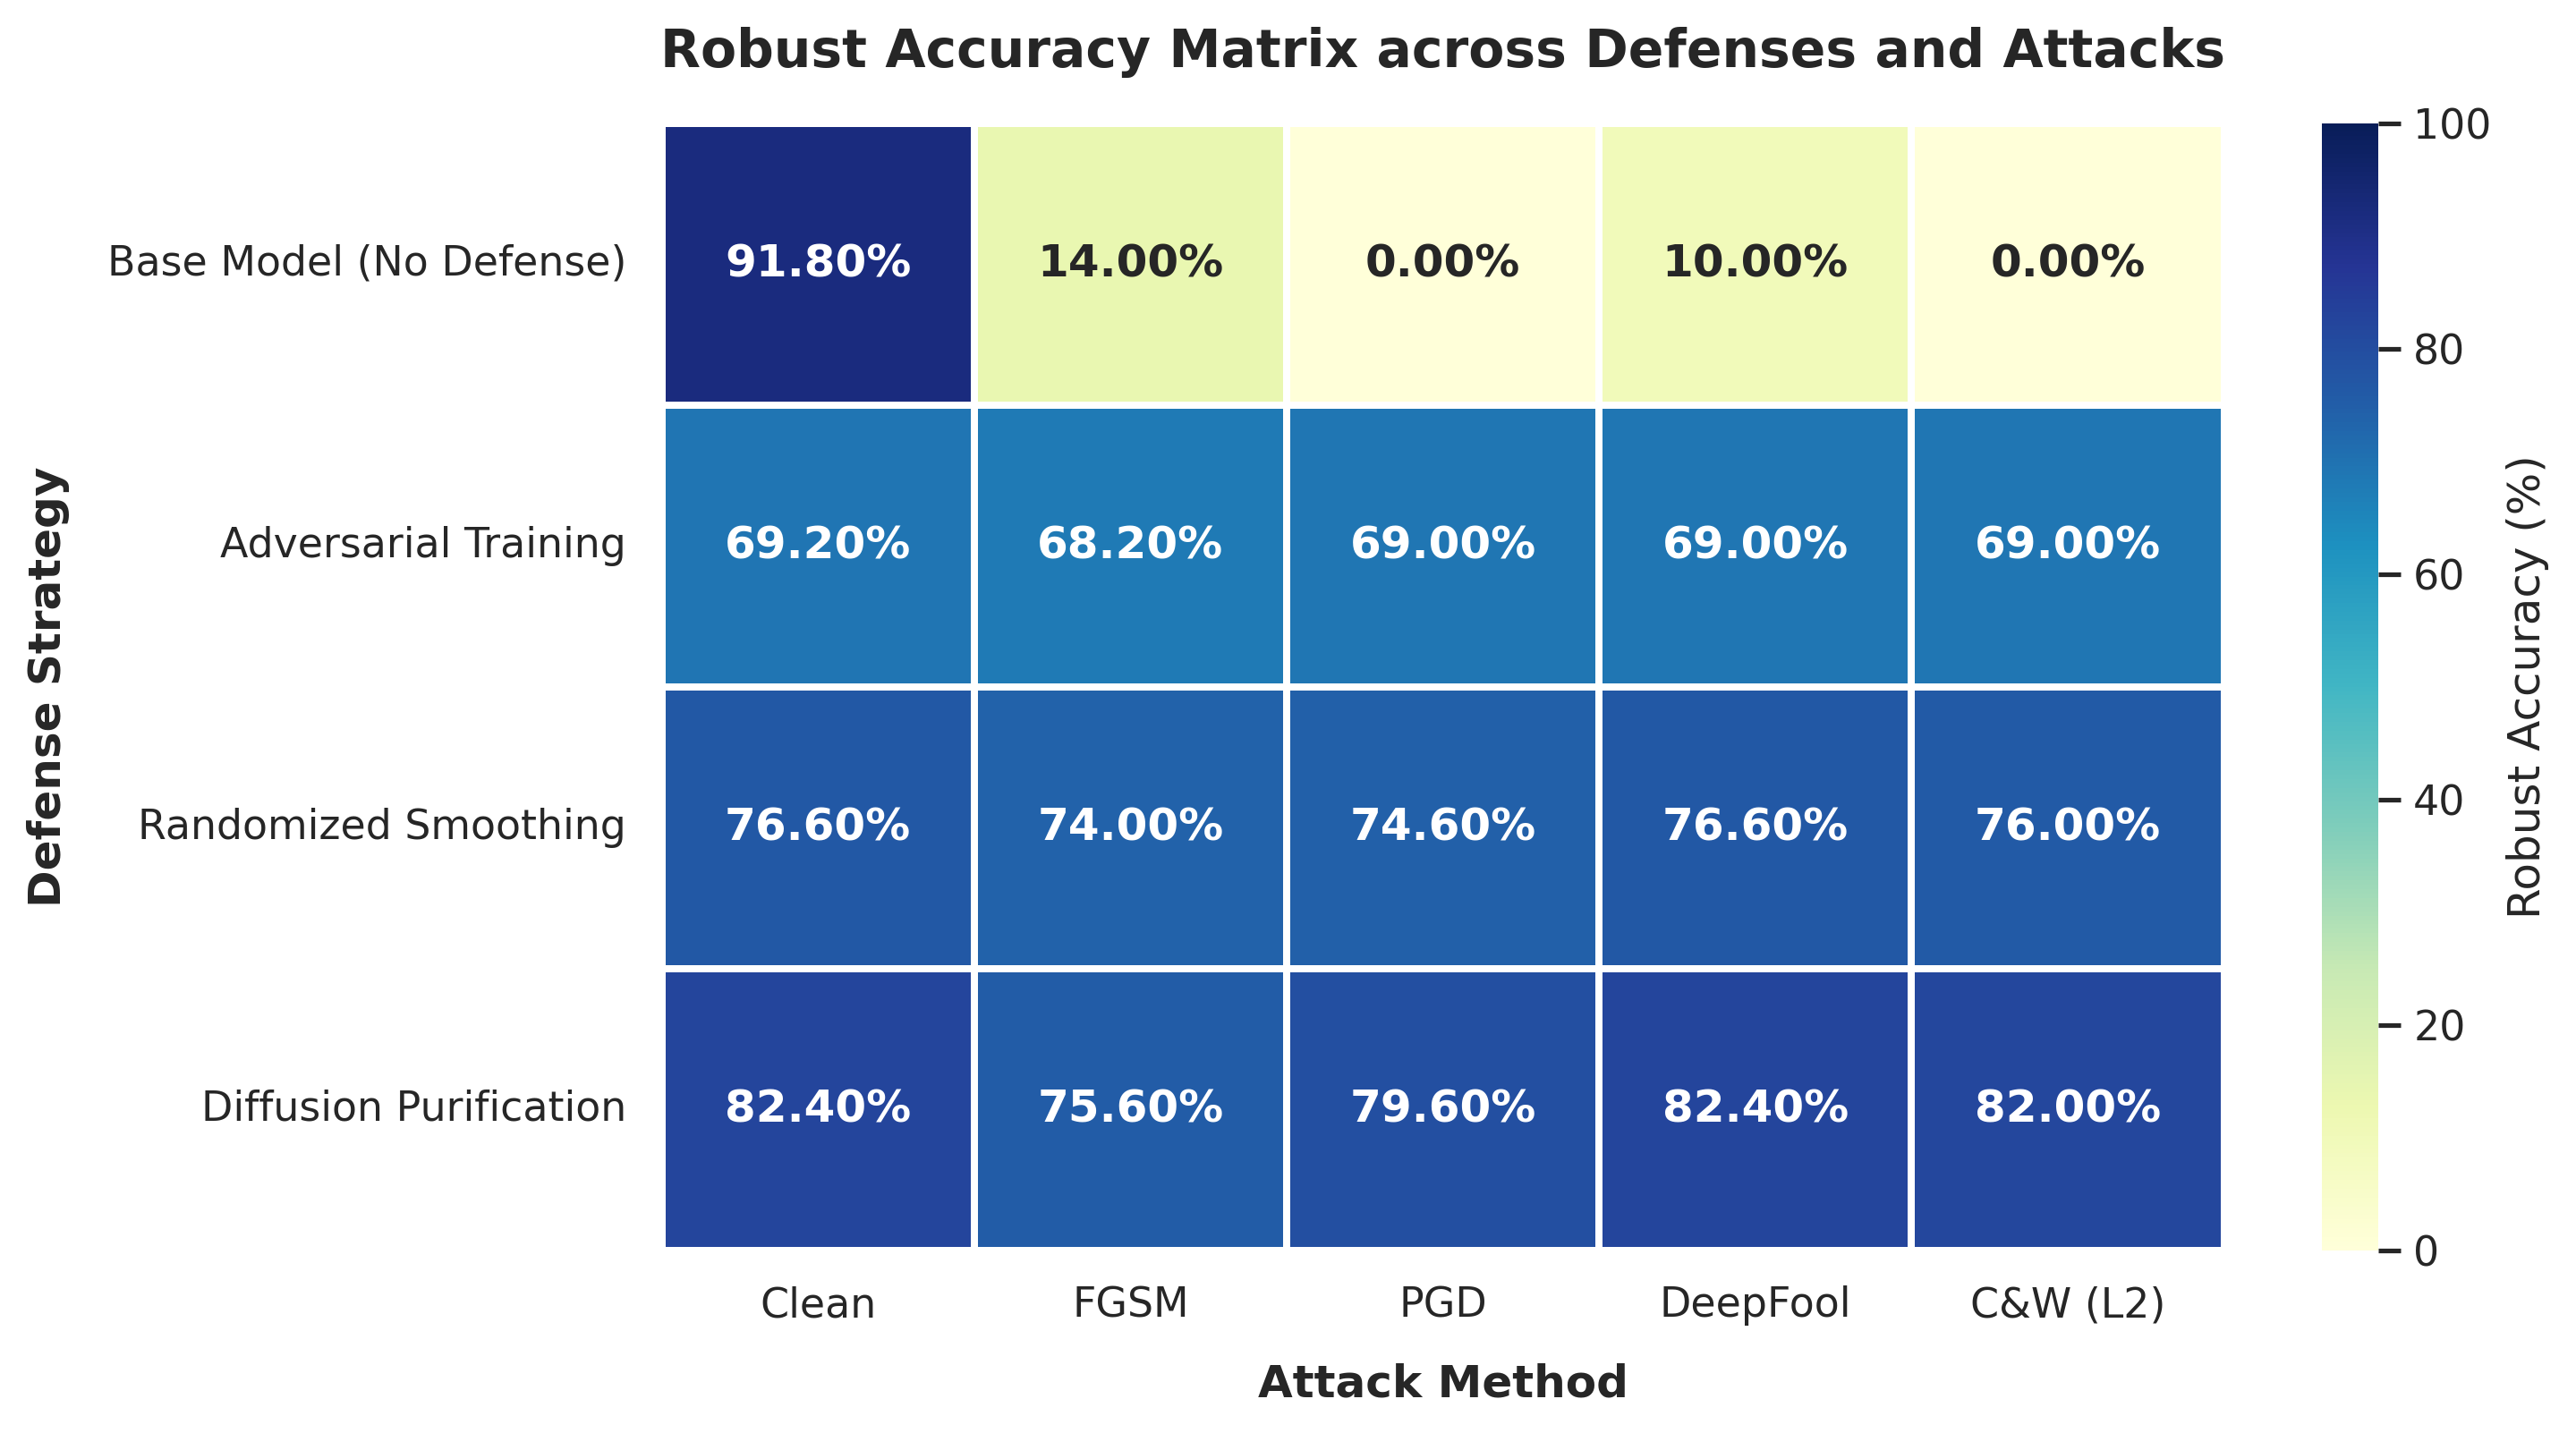

In [ ]:
def eval_base_on_samples(base_model, samples_list, device):
    base_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, target in samples_list:
            data = data.to(device)
            output = base_model(data)
            pred = output.argmax(dim=1).item()
            if pred == target:
                correct += 1
            total += 1
    return (correct / total) * 100.0

print("Evaluating Base Model on saved sample lists...")
base_clean_acc = eval_base_on_samples(model, clean_samples, device)
base_fgsm_acc  = eval_base_on_samples(model, fgsm_samples, device)
base_pgd_acc   = eval_base_on_samples(model, pgd_samples, device)
base_df_acc    = eval_base_on_samples(model, deepfool_samples, device)
base_cw_acc    = eval_base_on_samples(model, cw_l2_samples, device)
print("Base model evaluations complete!\n")

data_matrix = {
    'Clean': [
        base_clean_acc,
        adv_clean_acc,
        clean_acc,
        diffpure_clean_acc
    ],
    'FGSM': [
        base_fgsm_acc,
        adv_fgsm_acc,
        fgsm_acc,
        diffpure_fgsm_acc
    ],
    'PGD': [
        base_pgd_acc,
        adv_pgd_acc,
        pgd_acc,
        diffpure_pgd_acc
    ],
    'DeepFool': [
        base_df_acc,
        adv_deepfool_acc,
        deepfool_acc,
        diffpure_deepfool_acc
    ],
    'C&W (L2)': [
        base_cw_acc,
        adv_cw_acc,
        cw_l2_acc,
        diffpure_cw_acc
    ]
}

row_labels = [
    'Base Model (No Defense)',
    'Adversarial Training',
    'Randomized Smoothing',
    'Diffusion Purification'
]

df_results = pd.DataFrame(data_matrix, index=row_labels)

print("="*60)
print("             CROSS EVALUATION MATRIX (Robust Accuracy %)")
print("="*60)
print(df_results.round(2))
print("="*60 + "\n")

plt.figure(figsize=(10, 5.5), dpi=300)
sns.set_theme(style="white")

ax = sns.heatmap(
    df_results,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Robust Accuracy (%)'},
    linewidths=1.5,
    linecolor='white',
    vmin=0,
    vmax=100,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Robust Accuracy Matrix across Defenses and Attacks", fontsize=14, pad=15, weight='bold')
plt.xlabel("Attack Method", fontsize=12, labelpad=10, weight='bold')
plt.ylabel("Defense Strategy", fontsize=12, labelpad=10, weight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

for t in ax.texts:
    t.set_text(f"{float(t.get_text()):.2f}%")

plt.tight_layout()
plt.savefig("cross_evaluation_heatmap.png", bbox_inches='tight')
plt.show()

## Bonus Part


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from resnet20 import build_resnet20
from tqdm import tqdm

In [ ]:
BATCH_SIZE = 128
EPOCHS = 50
LR = 0.1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model = build_resnet20(
    num_classes=10,
    normalize_inside_model=True
).to(DEVICE)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_set = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/CIFAR10_Backup/data', train=True, transform=train_transform, download=False)
test_set = torchvision.datasets.CIFAR10(root='/content/drive/MyDrive/CIFAR10_Backup/data', train=False, transform=test_transform, download=False)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
def pgd_attack(model, images, labels, eps=8/255, alpha=2/255, steps=10):
    """Generates standard PGD adversarial examples on [0, 1] bounded images."""
    model.eval()

    noise = torch.empty_like(images).uniform_(-eps, eps)
    adv_images = torch.clamp(images + noise, 0.0, 1.0)

    for _ in range(steps):
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        grad = torch.autograd.grad(loss, adv_images)[0]

        adv_images = adv_images.detach() + alpha * grad.sign()

        delta = torch.clamp(adv_images - images, -eps, eps)

        adv_images = torch.clamp(images + delta, 0.0, 1.0)

    return adv_images

In [ ]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Starting Mixed Adversarial Training ({EPOCHS} Epochs) on device: {DEVICE}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    clean_correct = 0
    adv_correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch [{epoch}/{EPOCHS}]", leave=True)

    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        adv_images = pgd_attack(model, images, labels, eps=8/255, alpha=2/255, steps=10)

        model.train()
        optimizer.zero_grad()

        clean_outputs = model(images)
        adv_outputs = model(adv_images)

        loss_clean = criterion(clean_outputs, labels)
        loss_adv = criterion(adv_outputs, labels)
        loss = 0.5 * loss_clean + 0.5 * loss_adv

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total += batch_size

        clean_correct += clean_outputs.argmax(dim=1).eq(labels).sum().item()
        adv_correct += adv_outputs.argmax(dim=1).eq(labels).sum().item()

        current_loss = running_loss / total
        clean_acc = 100.0 * clean_correct / total
        adv_acc = 100.0 * adv_correct / total
        current_lr = scheduler.get_last_lr()[0]

        pbar.set_postfix({
            'Loss': f"{current_loss:.4f}",
            'Clean Acc': f"{clean_acc:.1f}%",
            'Adv Acc': f"{adv_acc:.1f}%",
            'LR': f"{current_lr:.4f}"
        })

    scheduler.step()

Starting Mixed Adversarial Training (50 Epochs) on device: cuda


Epoch [50/50]: 100%|██████████| 391/391 [01:29<00:00,  4.35it/s, Loss=0.9791, Clean Acc=83.9%, Adv Acc=46.2%, LR=0.0001]


In [ ]:
output_filename = "403105793.pt"
torch.save(model.state_dict(), output_filename)
print(f"\nModel weights saved to {output_filename}")


Model weights saved to 403105793.pt
